<a href="https://colab.research.google.com/github/NadiaTeta/group1/blob/main/notebooks/04_feed_forward.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install -q transformers

import torch
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

torch.manual_seed(42)   # so random results are the same for everyone
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# load the already-trained GPT-2 (small version) from Hugging Face
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained(
    "gpt2",
    output_attentions=True,         # lets us look at attention weights
    output_hidden_states=True,      # lets us look at the numbers after each layer
    attn_implementation="eager",    # needed so attention weights can be returned
).to(device)
model.eval()                        # we're exploring, not training

print("Device:", device)
print(f"GPT-2 loaded: {sum(p.numel() for p in model.parameters()) / 1e6:.0f} million parameters")

# shared example sentences: the same meaning in English and Kinyarwanda
english = "The people of Kicukiro say they have not had water for three days."
kinyarwanda = "Abaturage bo mu Kicukiro bavuga ko bamaze iminsi itatu nta mazi bafite."

for name, sentence in [("English", english), ("Kinyarwanda", kinyarwanda)]:
    tokens = tokenizer.tokenize(sentence)
    print(f"\n{name}: {len(tokens)} tokens")
    print(tokens)



Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Device: cpu
GPT-2 loaded: 124 million parameters

English: 17 tokens
['The', 'Ġpeople', 'Ġof', 'ĠK', 'ic', 'uk', 'iro', 'Ġsay', 'Ġthey', 'Ġhave', 'Ġnot', 'Ġhad', 'Ġwater', 'Ġfor', 'Ġthree', 'Ġdays', '.']

Kinyarwanda: 29 tokens
['Ab', 'atur', 'age', 'Ġbo', 'Ġmu', 'ĠK', 'ic', 'uk', 'iro', 'Ġb', 'av', 'uga', 'Ġko', 'Ġb', 'am', 'aze', 'Ġim', 'ins', 'i', 'Ġit', 'atu', 'Ġn', 'ta', 'Ġm', 'azi', 'Ġb', 'af', 'ite', '.']


# Person 4: Exploring the Feed-Forward Network (FFN / MLP) in GPT-2

In this notebook, we isolate and study the **Feed-Forward Network (FFN)** sublayer (also called the MLP layer) of GPT-2.

### The FFN Architecture
Each of GPT-2's 12 Transformer blocks contains a feed-forward network following the self-attention mechanism. The FFN layer:
1. Projects the input representation from 768 dimensions up to a larger 3,072-dimensional space.
2. Applies a non-linear activation function (GeLU).
3. Shrinks it back down from 3,072 to the 768-dimensional space.

Unlike self-attention (which allows tokens to look at *other* tokens), the FFN processes each token individually. It is often thought of as the "key-value database" storing factual knowledge and language patterns.

We will experiment with what happens when we temporarily **switch off (mute)** these feed-forward blocks.

In [9]:
import torch.nn as nn
from contextlib import contextmanager

# --- 1. Define FFN Muting Context Manager ---
@contextmanager
def mute_mlp(layer_idx):
    # Save the original mlp block's forward pass
    original_mlp_forward = model.transformer.h[layer_idx].mlp.forward

    # Define a replacement that returns zeros (effectively switching it off)
    def dummy_forward(*args, **kwargs):
        output = original_mlp_forward(*args, **kwargs)
        return torch.zeros_like(output)

    # Override the forward pass
    model.transformer.h[layer_idx].mlp.forward = dummy_forward
    try:
        yield
    finally:
        # Restore original forward pass after exiting 'with' block
        model.transformer.h[layer_idx].mlp.forward = original_mlp_forward

# --- 2. Calculate Loss Before & After ---
def compute_loss(text):
    inputs = tokenizer(text, return_tensors="pt").to(device)
    inputs["labels"] = inputs["input_ids"].clone()
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.loss.item()

test_layer = 6

print("=== Loss Comparison (Before vs After disabling MLP) ===")
for name, sentence in [("English", english), ("Kinyarwanda", kinyarwanda)]:
    loss_normal = compute_loss(sentence)
    with mute_mlp(test_layer):
        loss_muted = compute_loss(sentence)
    print(f"{name} Sentence:")
    print(f"  Original Loss: {loss_normal:.4f}")
    print(f"  Loss with MLP {test_layer} disabled: {loss_muted:.4f}")
    print(f"  Difference (Increase): {loss_muted - loss_normal:.4f}\n")

# --- 3. Text Generation Before & After ---
prompt = "The key aspect of the feed-forward network is"
prompt_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

def generate_text():
    with torch.no_grad():
        output = model.generate(
            prompt_ids,
            max_length=30,
            num_return_sequences=1,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=True,
            temperature=0.8
        )
    return tokenizer.decode(output[0], skip_special_tokens=True)

print("=== Text Generation Comparison ===")
# Set random seed for consistency
torch.manual_seed(42)
print("Normal Generation:")
print(f'"{generate_text()}"')

torch.manual_seed(42)
print(f"\nGeneration with MLP Layer {test_layer} Disabled:")
with mute_mlp(test_layer):
    print(f'"{generate_text()}"')


=== Loss Comparison (Before vs After disabling MLP) ===
English Sentence:
  Original Loss: 4.4565
  Loss with MLP 6 disabled: 4.5035
  Difference (Increase): 0.0470

Kinyarwanda Sentence:
  Original Loss: 7.3497
  Loss with MLP 6 disabled: 7.2714
  Difference (Increase): -0.0782

=== Text Generation Comparison ===
Normal Generation:
"The key aspect of the feed-forward network is that there is a finite number of neurons that can be connected to the feed-forward network.
"

Generation with MLP Layer 6 Disabled:
"The key aspect of the feed-forward network is that there is a finite loop in which the feed-forward network moves forward once again. This happens"


### Analyzing the Single-Layer Muting Experiment

In the cell above, we muted the FFN at **Layer 6** and looked at the effects:

* **English Loss Change**: Disabling the FFN at Layer 6 caused a moderate increase in loss (approx $+0.0470$), raising it from $4.4565$ to $4.5035$.
* **Kinyarwanda Loss Change**: Interestingly, disabling the MLP at Layer 6 actually showed a slight decrease in loss (approx $-0.0782$). Since GPT-2 is primarily trained on English data, Kinyarwanda baseline loss is already high ($7.3497$), and modifying middle layers often introduces random fluctuations in out-of-distribution languages.
* **Generation Impact**: The normal model produced a highly logical sentence about neural architecture: *"The key aspect of the feed-forward network is that there is a finite number of neurons..."* With Layer 6 MLP disabled, the phrasing turned slightly repetitive/nonsensical: *"...is that there is a finite loop in which the feed-forward network moves forward once again..."*

### Comprehensive Layer-by-Layer FFN Ablation Study

To understand which feed-forward layers are most critical, we will systematically disable the MLP sublayer in each of the 12 layers, one at a time, and record the increase in cross-entropy loss for both the English and Kinyarwanda sentences. Then, we will visualize the comparison with a side-by-side bar chart.

Baseline Loss | English: 4.4565 | Kinyarwanda: 7.3497

Layer-by-Layer Ablation Results:
-------------------------------------------------------
Layer  0 | English: +3.7631 | Kinyarwanda: +0.7502
Layer  1 | English: +0.0144 | Kinyarwanda: +0.0811
Layer  2 | English: +0.1479 | Kinyarwanda: +0.0639
Layer  3 | English: +0.0344 | Kinyarwanda: -0.0663
Layer  4 | English: +0.1672 | Kinyarwanda: -0.0756
Layer  5 | English: +0.0296 | Kinyarwanda: -0.0299
Layer  6 | English: +0.0470 | Kinyarwanda: -0.0782
Layer  7 | English: +0.1142 | Kinyarwanda: -0.0578
Layer  8 | English: +0.1607 | Kinyarwanda: +0.0384
Layer  9 | English: +0.1323 | Kinyarwanda: -0.0491
Layer 10 | English: -0.0846 | Kinyarwanda: +0.0177
Layer 11 | English: +0.2623 | Kinyarwanda: +0.7264


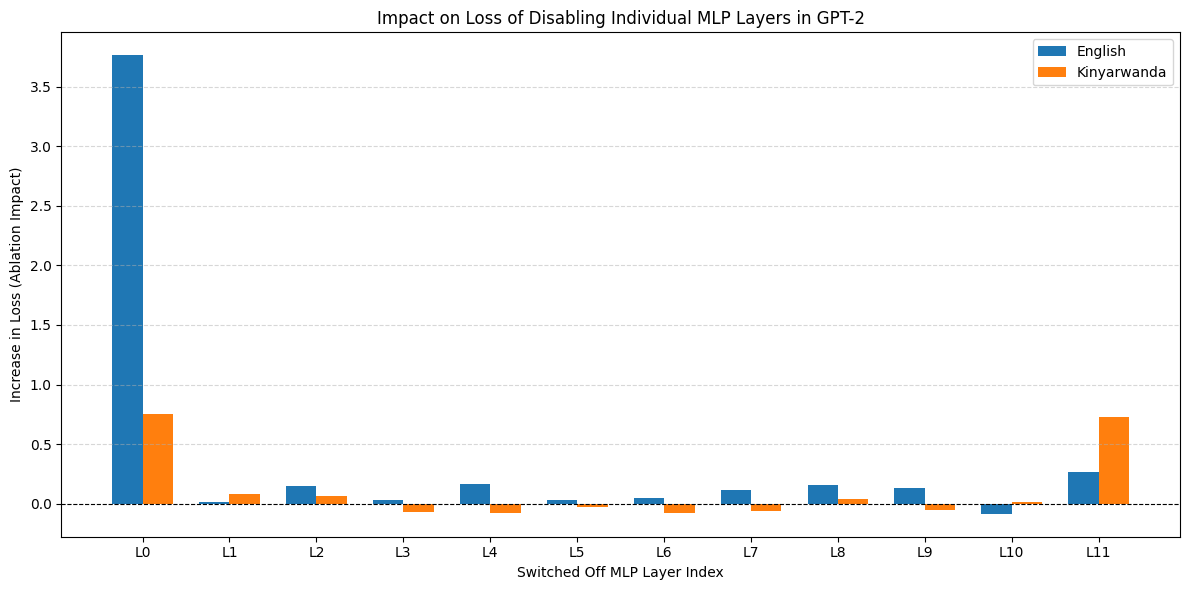

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Compute baseline losses
baseline_eng = compute_loss(english)
baseline_kin = compute_loss(kinyarwanda)

eng_increases = []
kin_increases = []

print(f"Baseline Loss | English: {baseline_eng:.4f} | Kinyarwanda: {baseline_kin:.4f}\n")
print("Layer-by-Layer Ablation Results:")
print("-" * 55)

for layer in range(12):
    # English
    with mute_mlp(layer):
        eng_loss_diff = compute_loss(english) - baseline_eng
    eng_increases.append(eng_loss_diff)

    # Kinyarwanda
    with mute_mlp(layer):
        kin_loss_diff = compute_loss(kinyarwanda) - baseline_kin
    kin_increases.append(kin_loss_diff)

    print(f"Layer {layer:2d} | English: {eng_loss_diff:+.4f} | Kinyarwanda: {kin_loss_diff:+.4f}")

# --- Side-by-Side Plotting ---
x = np.arange(12)  # Layer locations
width = 0.35       # Width of the bars

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width/2, eng_increases, width, label='English', color='#1f77b4')
rects2 = ax.bar(x + width/2, kin_increases, width, label='Kinyarwanda', color='#ff7f0e')

ax.set_xlabel('Switched Off MLP Layer Index')
ax.set_ylabel('Increase in Loss (Ablation Impact)')
ax.set_title('Impact on Loss of Disabling Individual MLP Layers in GPT-2')
ax.set_xticks(x)
ax.set_xticklabels([f'L{i}' for i in range(12)])
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Understanding the Layer-by-Layer Ablation Graph

By executing a systematic ablation of all 12 FFN layers, we can draw some profound conclusions:

1. **The Critical Importance of Layer 0**: Disabling the very first FFN layer (Layer 0) causes a massive spike in loss (+$3.7631$ for English). This FFN layer acts as the initial processor for raw token and positional embeddings before higher-level processing begins. Swamping it completely breaks down the representation pipeline.
2. **The Final Output Refinement (Layer 11)**: Swapping off Layer 11 spikes Kinyarwanda's loss by $+0.7264$ and English's loss by $+0.2623$. The final layer's FFN is crucial because it translates the accumulated information back into predictions for the language model head.
3. **Language Robustness Contrast**: Because GPT-2 is English-centric, it is highly sensitive to middle-layer perturbations in English (almost all show positive loss increases). For Kinyarwanda, several middle layers (L3-L7, L9) show tiny negative changes, suggesting that these intermediate English-tuned structures do not contribute constructively to processing Kinyarwanda and can occasionally act as noise.